# Isomap — Projet Final

## 1. Chargement des donnees

In [1]:
import warnings
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import Isomap

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

RANDOM_STATE = 42
CANDIDATE_ROOTS = [Path.cwd(), Path.cwd().parent]
PROJECT_ROOT = next((p for p in CANDIDATE_ROOTS if (p / 'data' / 'city_lifestyle_dataset.csv').exists()), None)
if PROJECT_ROOT is None:
    raise FileNotFoundError("Impossible de localiser le dossier projet contenant data/city_lifestyle_dataset.csv")

DATA_PATH = PROJECT_ROOT / 'data' / 'city_lifestyle_dataset.csv'
OUTPUT_DIR = PROJECT_ROOT / 'outputs'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(DATA_PATH)
print(f'Shape: {df.shape}')
df.head()

Shape: (300, 10)


,city_name,country,population_density,avg_income,internet_penetration,avg_rent,air_quality_index,public_transport_score,happiness_score,green_space_ratio
0,Old Vista,Europe,2775,3850,86.4,1310,43,52.0,8.5,23.8
1,Beachport,Europe,3861,3700,78.1,1330,42,62.8,8.1,33.1
2,Valleyborough,Europe,2562,4310,80.1,1330,39,73.2,8.5,40.2
3,City,Europe,3192,3970,81.2,1480,60,49.2,8.5,43.6
4,Falls,Europe,3496,4320,100.0,1510,64,93.7,8.5,42.5


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   city_name               300 non-null    object 
 1   country                 300 non-null    object 
 2   population_density      300 non-null    int64  
 3   avg_income              300 non-null    int64  
 4   internet_penetration    300 non-null    float64
 5   avg_rent                300 non-null    int64  
 6   air_quality_index       300 non-null    int64  
 7   public_transport_score  300 non-null    float64
 8   happiness_score         300 non-null    float64
 9   green_space_ratio       300 non-null    float64
dtypes: float64(4), int64(4), object(2)
memory usage: 23.6+ KB


In [5]:
df.describe()

,population_density,avg_income,internet_penetration,avg_rent,air_quality_index,public_transport_score,happiness_score,green_space_ratio
count,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000
mean,3944.843333,2827.200000,74.305333,1002.766667,71.246667,55.717333,6.644000,33.993333
std,2982.566777,1201.163939,17.014492,456.282066,25.344961,14.712549,1.685864,9.434067
min,100.000000,480.000000,34.000000,170.000000,22.000000,15.000000,2.500000,2.000000
25%,1830.000000,1907.500000,64.400000,640.000000,54.000000,46.075000,5.300000,28.225000
50%,3083.500000,2810.000000,75.000000,990.000000,67.500000,54.700000,6.900000,34.700000
75%,4823.750000,3752.500000,87.225000,1332.500000,86.000000,64.200000,8.500000,40.400000
max,14427.000000,5720.000000,100.000000,2430.000000,146.000000,95.000000,8.500000,58.000000


## 2. Preprocessing

On sélectionne uniquement les colonnes numériques et on standardise les données (moyenne 0, écart-type 1), car Isomap repose sur des distances entre points et est donc sensible aux échelles des variables.

In [7]:
# Colonnes numériques (on exclut city_name et country)
numeric_cols = df.select_dtypes(include=['number']).columns.tolist()
X = df[numeric_cols].copy()

if X.isna().any().any():
    raise ValueError('Valeurs manquantes detectees dans les colonnes numeriques. Nettoyer avant Isomap.')

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f'Variables numeriques: {len(numeric_cols)}')
print(f'Shape de X: {X.shape}')

Variables numeriques: 8
Shape de X: (300, 8)


## 3. Application d'Isomap et visualisation

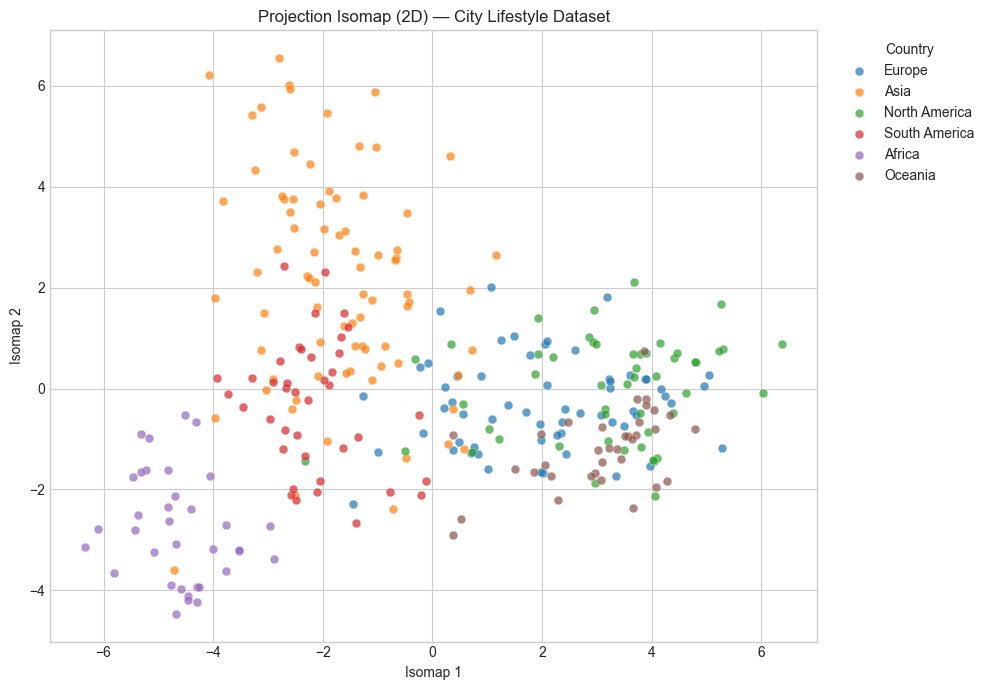

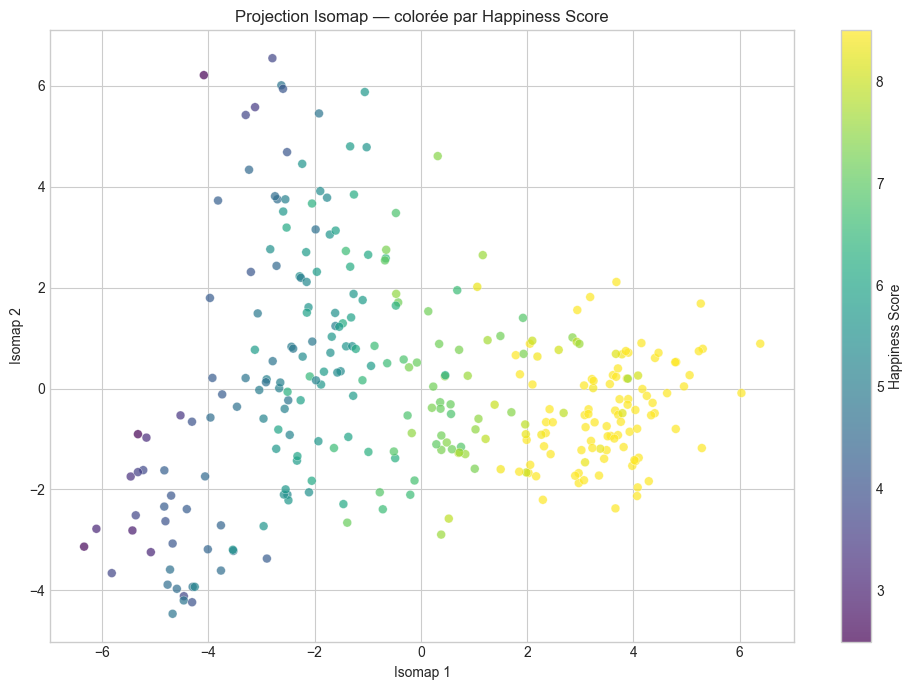

In [8]:
isomap_model = Isomap(
    n_components=2,
    n_neighbors=10
)

X_isomap = isomap_model.fit_transform(X_scaled)

# Visualisation colorée par continent/country
fig, ax = plt.subplots(figsize=(10, 7))

countries = df['country'].unique()
palette = sns.color_palette('tab10', n_colors=len(countries))

for i, country in enumerate(countries):
    mask = df['country'] == country
    ax.scatter(X_isomap[mask, 0], X_isomap[mask, 1],
               label=country, color=palette[i], alpha=0.7, s=40, edgecolors='w', linewidths=0.3)

ax.set_xlabel('Isomap 1')
ax.set_ylabel('Isomap 2')
ax.set_title('Projection Isomap (2D) — City Lifestyle Dataset')
ax.legend(title='Country', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/isomap_2d.png', dpi=150, bbox_inches='tight')
plt.show()


# Visualisation colorée par happiness_score pour voir une autre dimension
fig, ax = plt.subplots(figsize=(10, 7))

scatter = ax.scatter(X_isomap[:, 0], X_isomap[:, 1],
                     c=df['happiness_score'], cmap='viridis', alpha=0.7, s=40, edgecolors='w', linewidths=0.3)

plt.colorbar(scatter, label='Happiness Score')
ax.set_xlabel('Isomap 1')
ax.set_ylabel('Isomap 2')
ax.set_title('Projection Isomap — colorée par Happiness Score')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/isomap_happiness.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Observation

La projection Isomap produit une représentation plus continue et lisse que t-SNE ou UMAP, car elle préserve les distances géodésiques (le long de la variété) plutôt que les seules relations de voisinage local.

- On observe un gradient progressif plutôt que des clusters fortement séparés. Les villes d'un même continent se retrouvent dans des régions proches, mais avec des transitions graduelles entre groupes.
- La coloration par `happiness_score` montre une tendance spatiale cohérente, confirmant qu'Isomap capture bien les relations entre les variables numériques.

En résumé, Isomap est un bon complément aux autres méthodes : il fournit une vue globale de la structure non linéaire des données, là où t-SNE/UMAP accentuent davantage les clusters locaux.

## 5. Export des données 2D

In [9]:
df_isomap = pd.DataFrame(X_isomap, columns=['Isomap_1', 'Isomap_2'])
df_isomap['city_name'] = df['city_name'].values
df_isomap['country'] = df['country'].values

df_isomap.to_csv(f'{OUTPUT_DIR}/isomap_emb_2d.csv', index=False)
print("Export terminé : outputs/isomap_emb_2d.csv")
df_isomap.head()

Export terminé : outputs/isomap_emb_2d.csv


,Isomap_1,Isomap_2,city_name,country
0,2.355800,-0.664656,Old Vista,Europe
1,2.593162,0.766738,Beachport,Europe
2,3.613361,0.266660,Valleyborough,Europe
3,2.349703,-0.881579,City,Europe
4,4.950487,0.042465,Falls,Europe
